In [1]:
# ============================
# Anemia Detection Prediction (CNN+ViT)
# ============================

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# 2. Imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Layer
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# 3. Define custom layer
from tensorflow.keras.utils import register_keras_serializable

@register_keras_serializable()
class AddPositionEmbedding(Layer):
    def __init__(self, num_tokens, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_tokens = num_tokens
        self.embed_dim = embed_dim
        self.pos_emb = self.add_weight(
            shape=(1, num_tokens, embed_dim),
            initializer="random_normal",
            trainable=True,
            name="pos_embedding"
        )

    def call(self, x):
        return x + self.pos_emb


In [11]:
# 4. Load model with custom_objects
model_path = "/content/drive/MyDrive/New folder/Hybrid_Model_1(MobileNetV2,_DenseNet121).keras"
model = load_model(model_path, custom_objects={"AddPositionEmbedding": AddPositionEmbedding})
print("Model loaded successfully!")

Model loaded successfully!


In [12]:
# 5. Prediction helper
def predict_and_visualize(img_path, model, classes=["Anemic_individuals", "Healthy_individuals"]):
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    pred = model.predict(img_array)[0][0]
    percentage = pred * 100
    predicted_class = classes[1] if pred >= 0.5 else classes[0]

    # Show image
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {predicted_class}\nConfidence: {percentage:.2f}%")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


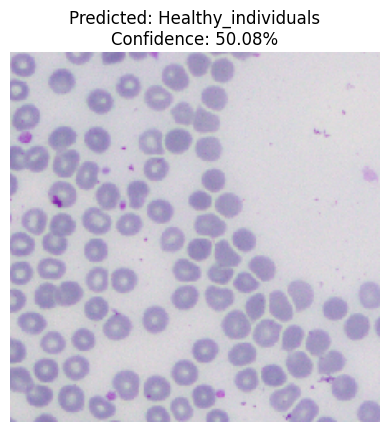

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


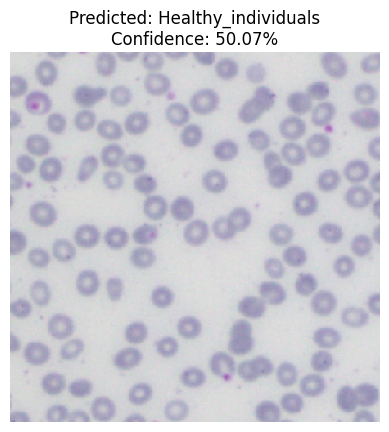

In [14]:
# 6. Test images
img_paths = [
    "/content/drive/MyDrive/New folder/Ane.png",
    "/content/drive/MyDrive/New folder/Helth.png"
]

for img_path in img_paths:
    predict_and_visualize(img_path, model)